In [3]:
# ================================================================
# STANDALONE: Replace router's Linear head with XGBoost
# (fresh Kaggle session - reconstructs model/transform code, loads saved
#  checkpoint + prediction banks from your previous run's output)
# ================================================================

import os, gc, io, json, random, hashlib, warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TVF
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, roc_auc_score,
)

import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| xgboost:", xgb.__version__)


# ----------------------------------------------------------------
# 0. CONFIG - EDIT THESE PATHS
# ----------------------------------------------------------------
# Same raw image dataset the original notebook used.
DATASET_ROOT = Path("/kaggle/input/datasets/nafisnahian/images-ff/ffpp_c23_extracted_dataset")
IMAGE_ROOT = DATASET_ROOT 
INPUT_METADATA_ROOT = DATASET_ROOT / "metadata"
FRAME_METADATA_CSV = INPUT_METADATA_ROOT / "ffpp_frame_metadata.csv"

# Attach your PREVIOUS kernel's saved output.zip as a Kaggle dataset input, then point
# this at the extracted "ffpp_xception_models_metadata" folder it contains. e.g.:
# /kaggle/input/<your-previous-kernel-output-dataset-slug>/ffpp_xception_models_metadata
PREV_ARTIFACT_ROOT = Path("/kaggle/input/notebooks/sleepytmzd/capstone-xception/ffpp_xception_models_metadata")

ROUTER_CHECKPOINT_PATH = PREV_ARTIFACT_ROOT / "checkpoints" / "MetaRouter" / "model_weights.pth"
PREDICTION_BANK_ROOT = PREV_ARTIFACT_ROOT / "prediction_banks"  # has "<method>_val_predictions.csv"

# Fresh output dir for this notebook's artifacts.
WORKING_DIR = Path("/kaggle/working")
RESULT_ROOT = WORKING_DIR / "results"
CHECKPOINT_ROOT = WORKING_DIR / "checkpoints"
for d in (RESULT_ROOT, CHECKPOINT_ROOT):
    d.mkdir(parents=True, exist_ok=True)

REAL_METHOD = "original"
FAKE_METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
ALL_METHODS = [REAL_METHOD, *FAKE_METHODS]
SPECIALIST_EXPERIMENTS = list(FAKE_METHODS)
ROUTER_CLASSES = [REAL_METHOD, *FAKE_METHODS]  # 0=real, 1..5=fake methods

RANDOM_SEED = 42
LOAD_SIZE = 320
CROP_SIZE = 299
XCEPTION_MEAN = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
XCEPTION_STD = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
BATCH_SIZE = 512
NUM_WORKERS = 32
USE_AMP = DEVICE.type == "cuda"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ----------------------------------------------------------------
# 1. Xception architecture (must match the original notebook exactly, so the
#    checkpoint's state_dict loads cleanly)
# ----------------------------------------------------------------
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, dilation,
                                groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)

    def forward(self, x):
        return self.pointwise(self.conv1(x))


class XceptionBlock(nn.Module):
    def __init__(self, in_filters, out_filters, reps, strides=1, start_with_relu=True, grow_first=True):
        super().__init__()
        if out_filters != in_filters or strides != 1:
            self.skip = nn.Conv2d(in_filters, out_filters, 1, stride=strides, bias=False)
            self.skipbn = nn.BatchNorm2d(out_filters)
        else:
            self.skip = None

        rep = []
        filters = in_filters
        if grow_first:
            rep += [nn.ReLU(inplace=True), SeparableConv2d(in_filters, out_filters, 3, 1, 1), nn.BatchNorm2d(out_filters)]
            filters = out_filters
        for _ in range(reps - 1):
            rep += [nn.ReLU(inplace=True), SeparableConv2d(filters, filters, 3, 1, 1), nn.BatchNorm2d(filters)]
        if not grow_first:
            rep += [nn.ReLU(inplace=True), SeparableConv2d(in_filters, out_filters, 3, 1, 1), nn.BatchNorm2d(out_filters)]
        if not start_with_relu:
            rep = rep[1:]
        else:
            rep[0] = nn.ReLU(inplace=False)
        if strides != 1:
            rep.append(nn.MaxPool2d(3, strides, 1))
        self.rep = nn.Sequential(*rep)

    def forward(self, inp):
        x = self.rep(inp)
        skip = self.skipbn(self.skip(inp)) if self.skip is not None else inp
        return x + skip


class Xception(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.block1 = XceptionBlock(64, 128, 2, 2, start_with_relu=False, grow_first=True)
        self.block2 = XceptionBlock(128, 256, 2, 2, start_with_relu=True, grow_first=True)
        self.block3 = XceptionBlock(256, 728, 2, 2, start_with_relu=True, grow_first=True)
        self.block4 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block5 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block6 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block7 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block8 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block9 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block10 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block11 = XceptionBlock(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block12 = XceptionBlock(728, 1024, 2, 2, start_with_relu=True, grow_first=False)
        self.conv3 = SeparableConv2d(1024, 1536, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(1536)
        self.conv4 = SeparableConv2d(1536, 2048, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(2048)
        self.fc = nn.Linear(2048, num_classes)

    def features(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        for i in range(1, 13):
            x = getattr(self, f"block{i}")(x)
        x = F.relu(self.bn3(self.conv3(x)), inplace=True)
        x = self.bn4(self.conv4(x))
        return x

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)
        return self.fc(x)


# ----------------------------------------------------------------
# 2. Load the previously-trained router checkpoint (6-way head)
# ----------------------------------------------------------------
router_model = Xception(num_classes=len(ROUTER_CLASSES)).to(DEVICE)
state_dict = torch.load(ROUTER_CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
router_model.load_state_dict(state_dict)
router_model.eval()
for p in router_model.parameters():
    p.requires_grad_(False)
print(f"Loaded router checkpoint from {ROUTER_CHECKPOINT_PATH}")


class XceptionEmbedder(nn.Module):
    """Exposes the router's 2048-d penultimate embedding instead of its class logits."""
    def __init__(self, xception_model: nn.Module):
        super().__init__()
        self.backbone = xception_model

    def forward(self, x):
        feats = self.backbone.features(x)
        feats = F.relu(feats, inplace=True)
        feats = F.adaptive_avg_pool2d(feats, (1, 1))
        return feats.view(feats.size(0), -1)


router_embedder = XceptionEmbedder(router_model).to(DEVICE).eval()


# ----------------------------------------------------------------
# 3. Frame metadata + router labels
# ----------------------------------------------------------------
frame_metadata = pd.read_csv(FRAME_METADATA_CSV)
frame_metadata = frame_metadata[frame_metadata["method"].isin(ALL_METHODS)].copy()
frame_metadata["image_path"] = frame_metadata["relative_image_path"].apply(lambda p: str(IMAGE_ROOT / p))

_method_to_router_label = {name: idx for idx, name in enumerate(ROUTER_CLASSES)}
frame_metadata["router_label"] = frame_metadata["method"].map(_method_to_router_label).astype(np.int64)
assert frame_metadata["router_label"].isna().sum() == 0
print("Rows:", len(frame_metadata), "| split counts:\n", frame_metadata["data_split"].value_counts())


# ----------------------------------------------------------------
# 4. Deterministic (val-style, no augmentation) transform + dataset
# ----------------------------------------------------------------
def repo_style_val_transform(image: Image.Image) -> torch.Tensor:
    image = image.convert("RGB").resize((LOAD_SIZE, LOAD_SIZE), resample=Image.Resampling.BILINEAR)
    offset = (LOAD_SIZE - CROP_SIZE) // 2
    image = image.crop((offset, offset, offset + CROP_SIZE, offset + CROP_SIZE))
    tensor = TVF.to_tensor(image)
    return (tensor - XCEPTION_MEAN) / XCEPTION_STD


class EmbeddingExtractionDataset(Dataset):
    def __init__(self, metadata: pd.DataFrame, row_indices, label_column: str = "router_label"):
        self.metadata = metadata
        self.row_indices = np.asarray(row_indices, dtype=np.int64)
        self.label_column = label_column

    def __len__(self):
        return len(self.row_indices)

    def __getitem__(self, index):
        row_index = int(self.row_indices[index])
        row = self.metadata.iloc[row_index]
        with Image.open(row["image_path"]) as image:
            tensor = repo_style_val_transform(image)
        label = torch.tensor(int(row[self.label_column]), dtype=torch.long)
        return tensor, label, row_index


def make_embedding_loader(data_split: str) -> DataLoader:
    indices = frame_metadata.index[frame_metadata["data_split"].eq(data_split)].to_numpy(dtype=np.int64)
    dataset = EmbeddingExtractionDataset(frame_metadata, indices)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True,
                       persistent_workers=(NUM_WORKERS > 0))


@torch.inference_mode()
def extract_embeddings(embedder: nn.Module, loader: DataLoader):
    embeddings_all, labels_all, row_indices_all = [], [], []
    for images, labels, row_indices in tqdm(loader, desc="extracting embeddings"):
        images = images.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            embeddings = embedder(images)
        embeddings_all.append(embeddings.float().cpu().numpy())
        labels_all.append(labels.numpy())
        row_indices_all.append(row_indices.numpy())
    X = np.concatenate(embeddings_all, axis=0)
    y = np.concatenate(labels_all, axis=0)
    row_indices = np.concatenate(row_indices_all, axis=0)
    return X, y, row_indices


# ----------------------------------------------------------------
# 5. Extract embeddings from the trained router backbone
# ----------------------------------------------------------------
print("Extracting train embeddings...")
X_train, y_train, train_row_indices = extract_embeddings(router_embedder, make_embedding_loader("train"))
print("Extracting val embeddings...")
X_val, y_val, val_row_indices = extract_embeddings(router_embedder, make_embedding_loader("val"))
print("X_train:", X_train.shape, " X_val:", X_val.shape)

np.savez_compressed(WORKING_DIR / "train_embeddings.npz", X=X_train, y=y_train, row_index=train_row_indices)
np.savez_compressed(WORKING_DIR / "val_embeddings.npz", X=X_val, y=y_val, row_index=val_row_indices)


# ----------------------------------------------------------------
# 6. Fit XGBoost as the new head
# ----------------------------------------------------------------
xgb_head = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(ROUTER_CLASSES),
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_lambda=1.0,
    tree_method="hist",
    device="cuda" if DEVICE.type == "cuda" else "cpu",
    eval_metric="mlogloss",
    early_stopping_rounds=50,   # move into .fit(...) if your xgboost version < 1.6
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_head.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

XGB_HEAD_DIR = CHECKPOINT_ROOT / "MetaRouter_xgb_head"
XGB_HEAD_DIR.mkdir(parents=True, exist_ok=True)
xgb_head.save_model(XGB_HEAD_DIR / "xgb_head.json")
print(f"Best iteration: {xgb_head.best_iteration}  best val mlogloss: {xgb_head.best_score:.4f}")


# ----------------------------------------------------------------
# 7. Evaluate the XGBoost-head router
# ----------------------------------------------------------------
xgb_val_probs = xgb_head.predict_proba(X_val)
xgb_val_preds = xgb_val_probs.argmax(axis=1)

print("\nXGBoost-head router accuracy:         ", accuracy_score(y_val, xgb_val_preds))
print("XGBoost-head router balanced accuracy:", balanced_accuracy_score(y_val, xgb_val_preds))

xgb_confusion_df = pd.DataFrame(
    confusion_matrix(y_val, xgb_val_preds, labels=list(range(len(ROUTER_CLASSES)))),
    index=ROUTER_CLASSES, columns=ROUTER_CLASSES,
)
xgb_confusion_df.to_csv(RESULT_ROOT / "xgb_head_confusion_matrix.csv")
print(xgb_confusion_df)


# ----------------------------------------------------------------
# 8. Load Stage-1 specialist prediction banks (from your previous run's output CSVs)
#    and rebuild the final ensemble scoring table
# ----------------------------------------------------------------
def binary_metrics_from_scores(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(np.float64)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "average_precision": float(average_precision_score(y_true, y_score)),
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float("nan"),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "real_accuracy": float(tn / max(tn + fp, 1)),
        "fake_accuracy": float(tp / max(tp + fn, 1)),
        "n": int(len(y_true)),
    }


stage1_banks = {}
for fake_method in SPECIALIST_EXPERIMENTS:
    bank_path = PREDICTION_BANK_ROOT / f"{fake_method}_val_predictions.csv"
    stage1_banks[fake_method] = pd.read_csv(bank_path)
    print(f"Loaded specialist bank: {fake_method} ({len(stage1_banks[fake_method]):,} rows)")

xgb_router_table = frame_metadata.loc[val_row_indices, ["method", "label", "data_split"]].copy()
xgb_router_table["row_index"] = val_row_indices
xgb_router_table["router_pred_class_idx"] = xgb_val_preds
xgb_router_table["router_pred_class_name"] = [ROUTER_CLASSES[i] for i in xgb_val_preds]
for class_idx, class_name in enumerate(ROUTER_CLASSES):
    xgb_router_table[f"router_prob_{class_name}"] = xgb_val_probs[:, class_idx]
xgb_router_table = xgb_router_table.set_index("row_index")

for fake_method in SPECIALIST_EXPERIMENTS:
    specialist_lookup = stage1_banks[fake_method].set_index("row_index")["prob_fake"]
    xgb_router_table[f"specialist_{fake_method}_prob_fake"] = xgb_router_table.index.map(specialist_lookup)

ensemble_scores = np.empty(len(xgb_router_table), dtype=np.float64)
predicted_names = xgb_router_table["router_pred_class_name"].to_numpy()

real_mask = predicted_names == REAL_METHOD
ensemble_scores[real_mask] = 1.0 - xgb_router_table.loc[real_mask, f"router_prob_{REAL_METHOD}"].to_numpy()
for fake_method in SPECIALIST_EXPERIMENTS:
    method_mask = predicted_names == fake_method
    ensemble_scores[method_mask] = xgb_router_table.loc[
        method_mask, f"specialist_{fake_method}_prob_fake"
    ].to_numpy()

xgb_router_table["ensemble_prob_fake"] = ensemble_scores
xgb_router_table = xgb_router_table.reset_index()
xgb_router_table.to_csv(RESULT_ROOT / "xgb_head_ensemble_predictions.csv", index=False)

print("\nRouting distribution:")
print(xgb_router_table["router_pred_class_name"].value_counts())


# ----------------------------------------------------------------
# 9. Per-method + overall ensemble metrics
# ----------------------------------------------------------------
rows = []
for test_method in FAKE_METHODS:
    subset = xgb_router_table[xgb_router_table["method"].isin([REAL_METHOD, test_method])]
    metrics = binary_metrics_from_scores(subset["label"].to_numpy(), subset["ensemble_prob_fake"].to_numpy())
    rows.append({"classifier": "Ensemble_XGBHead", "test_method": test_method, **metrics})

per_method_df = pd.DataFrame(rows)
per_method_df.to_csv(RESULT_ROOT / "xgb_head_per_method_metrics.csv", index=False)

overall_metrics = binary_metrics_from_scores(
    xgb_router_table["label"].to_numpy(), xgb_router_table["ensemble_prob_fake"].to_numpy()
)
with (RESULT_ROOT / "xgb_head_overall_metrics.json").open("w") as f:
    json.dump(overall_metrics, f, indent=2)

print("\nPer-method metrics:")
print(per_method_df.set_index("test_method")[
    ["balanced_accuracy", "average_precision", "roc_auc", "real_accuracy", "fake_accuracy"]
].round(4))

print("\nOVERALL metrics (entire val split, all methods combined):")
for key, value in overall_metrics.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

Device: cuda:0 | xgboost: 3.2.0
Loaded router checkpoint from /kaggle/input/notebooks/sleepytmzd/capstone-xception/ffpp_xception_models_metadata/checkpoints/MetaRouter/model_weights.pth
Rows: 600000 | split counts:
 data_split
train    540000
val       60000
Name: count, dtype: int64
Extracting train embeddings...


extracting embeddings:   0%|          | 0/1055 [00:00<?, ?it/s]

Extracting val embeddings...


extracting embeddings:   0%|          | 0/118 [00:01<?, ?it/s]

X_train: (540000, 2048)  X_val: (60000, 2048)
[0]	validation_0-mlogloss:1.69065
[50]	validation_0-mlogloss:0.70539
[100]	validation_0-mlogloss:0.80023
[105]	validation_0-mlogloss:0.81464
Best iteration: 55  best val mlogloss: 0.7041

XGBoost-head router accuracy:          0.7923
XGBoost-head router balanced accuracy: 0.7923
                original  Deepfakes  Face2Face  FaceShifter  FaceSwap  \
original            6774         69        535          771       788   
Deepfakes            542       8662        129          205       127   
Face2Face            719        141       8159          316       448   
FaceShifter          487         49        187         8890        88   
FaceSwap             639         61        190           73      8645   
NeuralTextures      1930         82        309          792       479   

                NeuralTextures  
original                  1063  
Deepfakes                  335  
Face2Face                  217  
FaceShifter                299

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [08:16:10] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Loaded specialist bank: Deepfakes (60,000 rows)
Loaded specialist bank: Face2Face (60,000 rows)
Loaded specialist bank: FaceShifter (60,000 rows)
Loaded specialist bank: FaceSwap (60,000 rows)
Loaded specialist bank: NeuralTextures (60,000 rows)

Routing distribution:
router_pred_class_name
original          11091
FaceShifter       11047
FaceSwap          10575
Face2Face          9509
Deepfakes          9064
NeuralTextures     8714
Name: count, dtype: int64

Per-method metrics:
                balanced_accuracy  average_precision  roc_auc  real_accuracy  \
test_method                                                                    
Deepfakes                  0.8574             0.9486   0.9323         0.8073   
Face2Face                  0.8298             0.9270   0.8930         0.8073   
FaceShifter                0.8582             0.9505   0.9326         0.8073   
FaceSwap                   0.8333             0.9223   0.8996         0.8073   
NeuralTextures             0.7408    

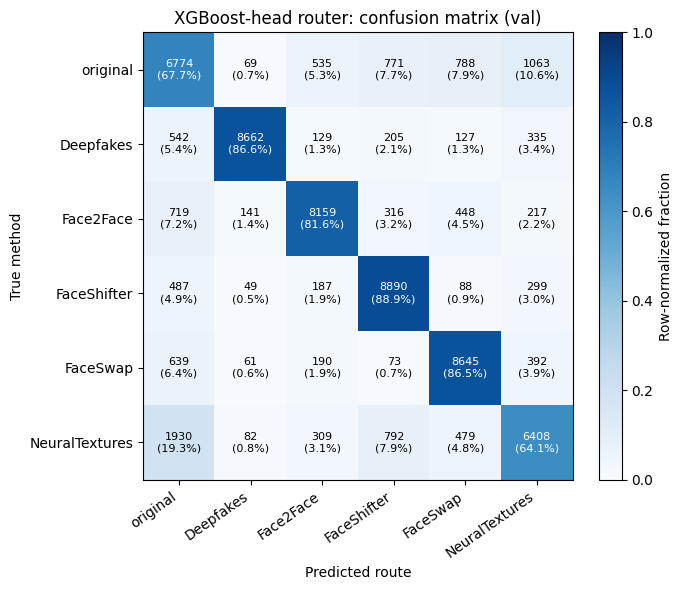

/tmp/ipykernel_163/3427172631.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=35, ha="right")


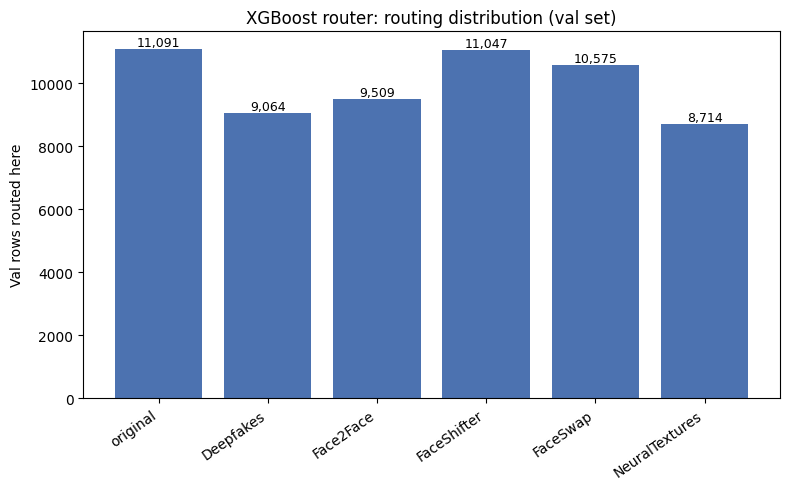

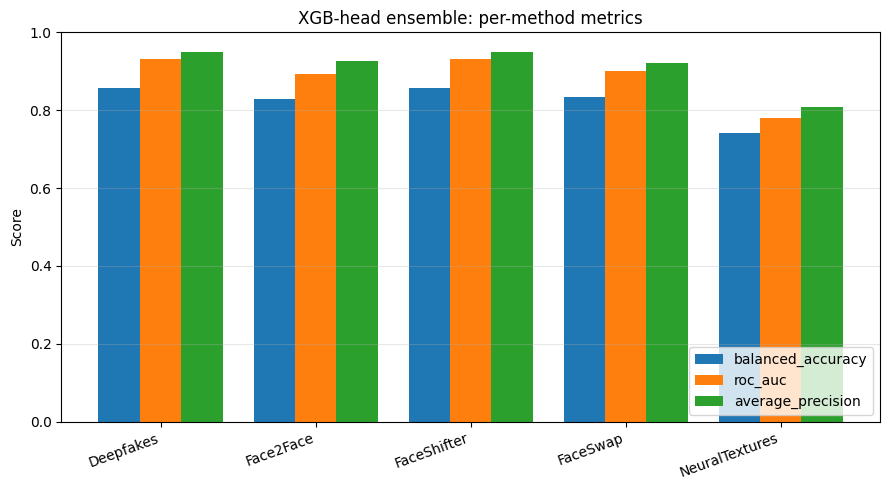

/tmp/ipykernel_163/3427172631.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=20, ha="right")


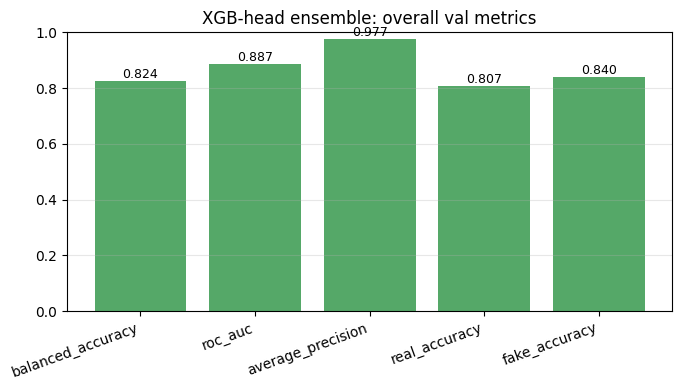

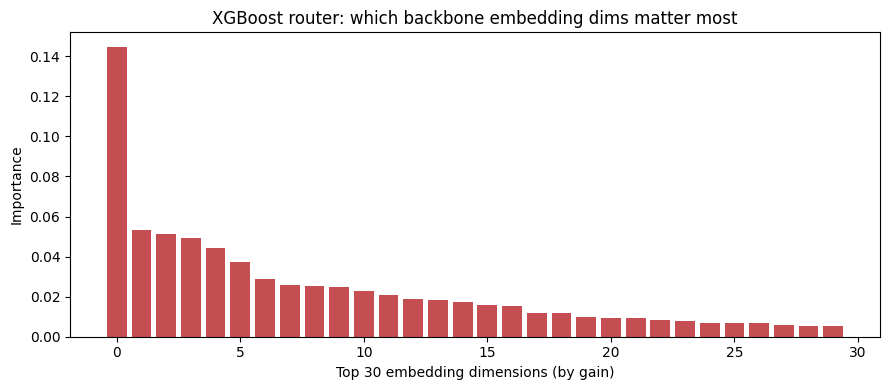

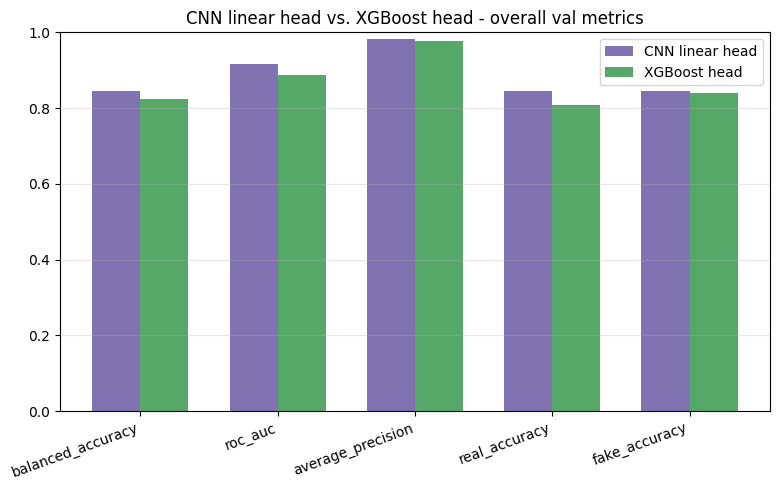

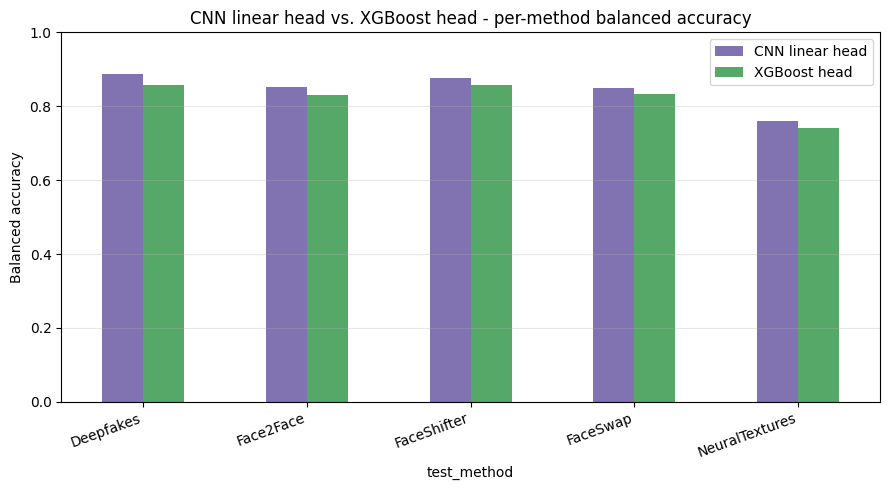


Saved CNN-vs-XGB comparison plots.

All plots saved to: /kaggle/working/plots


In [4]:
# ================================================================
# COMPARISON PLOTS
# ================================================================
import matplotlib.pyplot as plt

PLOT_ROOT = WORKING_DIR / "plots"
PLOT_ROOT.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------------
# 1. XGB-head router confusion matrix (normalized, annotated heatmap)
# ----------------------------------------------------------------
def plot_confusion_matrix(cm, class_names, title, out_name):
    cm = np.asarray(cm, dtype=np.float64)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=35, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted route")
    ax.set_ylabel("True method")
    ax.set_title(title)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            color = "white" if cm_norm[r, c] > 0.5 else "black"
            ax.text(c, r, f"{cm[r, c]:.0f}\n({cm_norm[r, c]:.1%})",
                    ha="center", va="center", fontsize=8, color=color)
    fig.colorbar(im, ax=ax, label="Row-normalized fraction")
    fig.tight_layout()
    fig.savefig(PLOT_ROOT / out_name, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


xgb_cm = confusion_matrix(y_val, xgb_val_preds, labels=list(range(len(ROUTER_CLASSES))))
plot_confusion_matrix(xgb_cm, ROUTER_CLASSES, "XGBoost-head router: confusion matrix (val)",
                       "xgb_head_confusion_matrix.png")


# ----------------------------------------------------------------
# 2. Routing distribution (bar chart, true method vs. what the router predicted)
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
counts = xgb_router_table["router_pred_class_name"].value_counts().reindex(ROUTER_CLASSES, fill_value=0)
bars = ax.bar(counts.index, counts.values, color="#4C72B0")
ax.set_ylabel("Val rows routed here")
ax.set_title("XGBoost router: routing distribution (val set)")
ax.set_xticklabels(counts.index, rotation=35, ha="right")
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_ROOT / "routing_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)


# ----------------------------------------------------------------
# 3. Per-method ensemble metrics (grouped bar chart)
# ----------------------------------------------------------------
def plot_per_method_metrics(per_method_df, metric_cols, title, out_name):
    x = np.arange(len(per_method_df))
    width = 0.8 / len(metric_cols)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, metric in enumerate(metric_cols):
        ax.bar(x + i * width, per_method_df[metric], width, label=metric)
    ax.set_xticks(x + width * (len(metric_cols) - 1) / 2)
    ax.set_xticklabels(per_method_df["test_method"], rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_ROOT / out_name, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_per_method_metrics(
    per_method_df, ["balanced_accuracy", "roc_auc", "average_precision"],
    "XGB-head ensemble: per-method metrics", "xgb_head_per_method_metrics.png",
)


# ----------------------------------------------------------------
# 4. Overall metrics summary (single-run bar chart)
# ----------------------------------------------------------------
def plot_overall_metrics(overall_dict, title, out_name):
    keys = ["balanced_accuracy", "roc_auc", "average_precision", "real_accuracy", "fake_accuracy"]
    values = [overall_dict[k] for k in keys]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(keys, values, color="#55A868")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xticklabels(keys, rotation=20, ha="right")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_ROOT / out_name, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_overall_metrics(overall_metrics, "XGB-head ensemble: overall val metrics",
                      "xgb_head_overall_metrics.png")


# ----------------------------------------------------------------
# 5. XGBoost feature importance (which embedding dims drove the routing decision)
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
importances = xgb_head.feature_importances_
top_k = 30
top_idx = np.argsort(importances)[::-1][:top_k]
ax.bar(range(top_k), importances[top_idx], color="#C44E52")
ax.set_xlabel(f"Top {top_k} embedding dimensions (by gain)")
ax.set_ylabel("Importance")
ax.set_title("XGBoost router: which backbone embedding dims matter most")
fig.tight_layout()
fig.savefig(PLOT_ROOT / "xgb_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)


# ----------------------------------------------------------------
# 6. OPTIONAL: side-by-side CNN-linear-head vs XGB-head comparison, if you have the
#    original CNN router's saved metrics files from your previous Kaggle run. Point
#    these at the previous output's RESULT_ROOT-equivalent CSV/JSON files.
# ----------------------------------------------------------------
PREV_STAGE3_OVERALL_JSON = PREV_ARTIFACT_ROOT / "results" / "stage3_overall_metrics.json"
PREV_STAGE3_PER_METHOD_CSV = PREV_ARTIFACT_ROOT / "results" / "stage3_per_method_metrics.csv"

if PREV_STAGE3_OVERALL_JSON.exists() and PREV_STAGE3_PER_METHOD_CSV.exists():
    with PREV_STAGE3_OVERALL_JSON.open() as f:
        cnn_overall = json.load(f)
    cnn_per_method = pd.read_csv(PREV_STAGE3_PER_METHOD_CSV)

    # --- overall comparison ---
    keys = ["balanced_accuracy", "roc_auc", "average_precision", "real_accuracy", "fake_accuracy"]
    x = np.arange(len(keys))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width / 2, [cnn_overall[k] for k in keys], width, label="CNN linear head", color="#8172B2")
    ax.bar(x + width / 2, [overall_metrics[k] for k in keys], width, label="XGBoost head", color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(keys, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title("CNN linear head vs. XGBoost head - overall val metrics")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_ROOT / "cnn_vs_xgb_overall.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # --- per-method comparison (balanced accuracy) ---
    merged = cnn_per_method.set_index("test_method")["balanced_accuracy"].rename("CNN linear head").to_frame()
    merged["XGBoost head"] = per_method_df.set_index("test_method")["balanced_accuracy"]

    fig, ax = plt.subplots(figsize=(9, 5))
    merged.plot(kind="bar", ax=ax, color=["#8172B2", "#55A868"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Balanced accuracy")
    ax.set_title("CNN linear head vs. XGBoost head - per-method balanced accuracy")
    ax.set_xticklabels(merged.index, rotation=20, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOT_ROOT / "cnn_vs_xgb_per_method.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("\nSaved CNN-vs-XGB comparison plots.")
else:
    print("\nPrevious CNN-router metrics not found at expected path - skipping side-by-side comparison plots.")
    print(f"  looked for: {PREV_STAGE3_OVERALL_JSON}")
    print(f"  looked for: {PREV_STAGE3_PER_METHOD_CSV}")

print(f"\nAll plots saved to: {PLOT_ROOT}")